# 🔍 Análise de Anomalias — Prestações de Contas (mai/2022–jun/2026)

Notebook especializado para **análise aprofundada** das anomalias detectadas nas prestações de contas.

**Fonte de dados**: `exports/csv/anomalias_prestacoes.csv` (gerado por `analise_prestacao_de_contas.ipynb`)

**Objetivo**:
- Investigar distribuição de anomalias por tipo e período
- Identificar padrões recorrentes
- Priorizar itens para ação
- Exportar insights para relatório

⚠️ **Importante**: Este notebook trabalha APENAS com dados de prestações. Não cruza com extratos ou outras fontes.

In [2]:
import re
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 6)})
sns.set_theme(style="whitegrid", palette="tab10")

CSV_DIR = Path("../exports/csv")
EXPORT_PREFIX = "insights_anomalias_prestacoes"

print("✓ Imports completos")

✓ Imports completos


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# GUARDRAIL: Verificar que APENAS prestações são carregadas
# ═══════════════════════════════════════════════════════════════════════════

arquivos_csv_existentes = list(CSV_DIR.glob("anomalias_*.csv"))
print(f"Arquivos de anomalias disponíveis: {[f.name for f in arquivos_csv_existentes]}")

# Garantir que carregamos APENAS prestações
anomalias_file = CSV_DIR / "anomalias_prestacoes.csv"
assert anomalias_file.exists(), f"❌ Arquivo {anomalias_file} não encontrado!"
print(f"✓ Carregando fonte única: {anomalias_file.name}")

Arquivos de anomalias disponíveis: ['anomalias_prestacoes.csv']
✓ Carregando fonte única: anomalias_prestacoes.csv


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# 1. Carregar e tipificar dados
# ═══════════════════════════════════════════════════════════════════════════

df_anom = pd.read_csv(anomalias_file, dtype={
    "mes_ano": str,
    "evento": str,
    "tipo": str,
    "valor": float,
    "macro_categoria": str,
    "motivo_anomalia": str,
})

print(f"\n=== Dados Carregados ===")
print(f"Total de anomalias: {len(df_anom):,}")
print(f"Período: {df_anom['mes_ano'].min()} → {df_anom['mes_ano'].max()}")
print(f"Meses únicos: {df_anom['mes_ano'].nunique()}")
print(f"\nTipos de evento: {df_anom['tipo'].unique().tolist()}")
print(f"Macro-categorias: {df_anom['macro_categoria'].nunique()} únicas")

print(f"\n=== Qualidade dos Dados ===")
print(f"Nulos por coluna:")
print(df_anom.isnull().sum())


=== Dados Carregados ===
Total de anomalias: 196
Período: 2022-05 → 2026-06
Meses únicos: 44

Tipos de evento: ['DESPESA', 'RECEITA']
Macro-categorias: 1 únicas

=== Qualidade dos Dados ===
Nulos por coluna:
evento             0
valor              0
tipo               0
mes_ano            0
macro_categoria    0
motivo_anomalia    0
dtype: int64


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 2. Distribuição de anomalias por tipo (motivo)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("RANKING: Anomalias por tipo (motivo)")
print("="*80)

tipo_count = df_anom["motivo_anomalia"].value_counts()
tipo_pct = (tipo_count / len(df_anom) * 100).round(2)

ranking_tipo = pd.DataFrame({
    "Tipo de Anomalia": tipo_count.index,
    "Qtd": tipo_count.values,
    "%": tipo_pct.values,
    "Valor Total R$": [df_anom[df_anom['motivo_anomalia']==t]['valor'].sum() for t in tipo_count.index],
    "Valor Médio R$": [df_anom[df_anom['motivo_anomalia']==t]['valor'].mean() for t in tipo_count.index],
})

print(ranking_tipo.to_string(index=False))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: quantidade
axes[0].barh(tipo_count.index, tipo_count.values, color="#e74c3c", alpha=0.8)
axes[0].set_xlabel("Quantidade")
axes[0].set_title("Anomalias por tipo — Quantidade", fontsize=11)
for i, v in enumerate(tipo_count.values):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=9)

# Barras: valor total
valor_total = [df_anom[df_anom['motivo_anomalia']==t]['valor'].sum() for t in tipo_count.index]
axes[1].barh(tipo_count.index, valor_total, color="#3498db", alpha=0.8)
axes[1].set_xlabel("Valor Total (R$)")
axes[1].set_title("Anomalias por tipo — Valor acumulado", fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 3. Tendência mensal de anomalias
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("TENDÊNCIA: Anomalias por mês")
print("="*80)

mensal = df_anom.groupby("mes_ano").agg({
    "motivo_anomalia": "count",
    "valor": ["sum", "mean"],
}).round(2)

mensal.columns = ["Qtd", "Valor Total R$", "Valor Médio R$"]
print(mensal.to_string())

# Gráfico duplo
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Painel 1: Quantidade
axes[0].bar(mensal.index, mensal["Qtd"], color="#2ecc71", alpha=0.8, label="Quantidade")
axes[0].plot(mensal.index, mensal["Qtd"], color="#27ae60", marker="o", linewidth=2, markersize=5, label="Série")
axes[0].set_ylabel("Quantidade")
axes[0].set_title("Anomalias — Evolução mensal (quantidade)", fontsize=11)
axes[0].legend(fontsize=9)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)

# Painel 2: Valor
axes[1].bar(mensal.index, mensal["Valor Total R$"], color="#3498db", alpha=0.8, label="Valor Total")
axes[1].plot(mensal.index, mensal["Valor Total R$"], color="#2980b9", marker="s", linewidth=2, markersize=5, label="Série")
axes[1].set_ylabel("R$")
axes[1].set_title("Anomalias — Evolução mensal (valor acumulado)", fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
axes[1].legend(fontsize=9)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4. Heatmap: motivo_anomalia × mes_ano
# ═══════════════════════════════════════════════════════════════════════════

heatmap_data = df_anom.pivot_table(
    index="motivo_anomalia",
    columns="mes_ano",
    values="valor",
    aggfunc="count",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "Quantidade"},
            ax=ax, linewidths=0.5, linecolor="gray")
ax.set_title("Heatmap: Tipo de Anomalia × Período", fontsize=12, pad=15)
ax.set_xlabel("Período (mes_ano)")
ax.set_ylabel("Tipo de Anomalia")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("✓ Heatmap exibido")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5. Eventos recorrentes (top 20)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("TOP 20: Eventos mais frequentes em anomalias")
print("="*80)

top_eventos = df_anom["evento"].value_counts().head(20)
print(top_eventos.to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(top_eventos)), top_eventos.values, color=plt.cm.tab20(np.linspace(0, 1, len(top_eventos))))
ax.set_yticks(range(len(top_eventos)))
ax.set_yticklabels(top_eventos.index, fontsize=9)
ax.set_xlabel("Quantidade")
ax.set_title("Top 20 Eventos em Anomalias", fontsize=12)
for i, v in enumerate(top_eventos.values):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 6. Análise de severidade (percentis de valor)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SEVERIDADE: Análise de valores")
print("="*80)

percentis = [10, 25, 50, 75, 90, 95, 99]
severity = pd.DataFrame({
    "Percentil": percentis,
    "Valor R$": [df_anom["valor"].quantile(p/100) for p in percentis],
})

print(severity.to_string(index=False))

# Classificação de severidade
def classificar_severidade(valor, perc_75, perc_90, perc_99):
    if valor >= perc_99:
        return "Crítica"
    elif valor >= perc_90:
        return "Alta"
    elif valor >= perc_75:
        return "Média"
    else:
        return "Baixa"

p75, p90, p99 = df_anom["valor"].quantile([0.75, 0.90, 0.99])
df_anom["severidade"] = df_anom["valor"].apply(lambda v: classificar_severidade(v, p75, p90, p99))

print("\nDistribuição por severidade:")
print(df_anom["severidade"].value_counts().sort_index(ascending=False))

# Gráfico
cores_sev = {"Crítica": "#e74c3c", "Alta": "#e67e22", "Média": "#f39c12", "Baixa": "#95a5a6"}
sev_order = ["Crítica", "Alta", "Média", "Baixa"]

fig, ax = plt.subplots(figsize=(10, 6))
sev_counts = df_anom["severidade"].value_counts().reindex(sev_order)
cores = [cores_sev[s] for s in sev_order]
ax.bar(sev_order, sev_counts.values, color=cores, alpha=0.8, edgecolor="black", linewidth=1.5)
ax.set_ylabel("Quantidade")
ax.set_title("Distribuição de Anomalias por Severidade", fontsize=12)
ax.set_ylim(0, sev_counts.max() * 1.15)

for i, (s, v) in enumerate(zip(sev_order, sev_counts.values)):
    pct = v / len(df_anom) * 100
    ax.text(i, v + 2, f"{v}\n({pct:.1f}%)", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 7. Análise por macro_categoria
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("ANÁLISE POR CATEGORIA: Distribuição de anomalias")
print("="*80)

por_cat = df_anom.groupby("macro_categoria").agg({
    "motivo_anomalia": "count",
    "valor": ["sum", "mean"],
})

por_cat.columns = ["Qtd", "Valor Total R$", "Valor Médio R$"]
por_cat = por_cat.sort_values("Qtd", ascending=False)

print(por_cat.to_string())

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras: quantidade por categoria
axes[0].barh(por_cat.index, por_cat["Qtd"], color="#9b59b6", alpha=0.8)
axes[0].set_xlabel("Quantidade")
axes[0].set_title("Anomalias por Macro-Categoria (Qtd)", fontsize=11)

# Barras: valor por categoria
axes[1].barh(por_cat.index, por_cat["Valor Total R$"], color="#16a085", alpha=0.8)
axes[1].set_xlabel("Valor Total (R$)")
axes[1].set_title("Anomalias por Macro-Categoria (Valor)", fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))

plt.tight_layout()
plt.show()


PAGAMENTOS: INSS e Adiantamentos de Funcionários

INSS — pagamentos encontrados:
mes_ano                           evento    tipo   valor macro_categoria              motivo_anomalia
2024-05  Prov.darf Inss(E-Social/Reinf)  DESPESA 1559.77          Outros Evento sem categoria mapeada
2024-06  Prov.darf Inss(E-Social/Reinf)  DESPESA 1489.57          Outros Evento sem categoria mapeada
  Total INSS: 2 lançamentos | R$ 3,049.34

Adiantamentos de Funcionários — pagamentos encontrados:
mes_ano             evento    tipo   valor macro_categoria              motivo_anomalia
2022-09  Adto.13º Salário  DESPESA  933.75          Outros Evento sem categoria mapeada
2024-05  Adto.13º Salário  DESPESA 1638.00          Outros Evento sem categoria mapeada
  Total Adiantamentos: 2 lançamentos | R$ 2,571.75


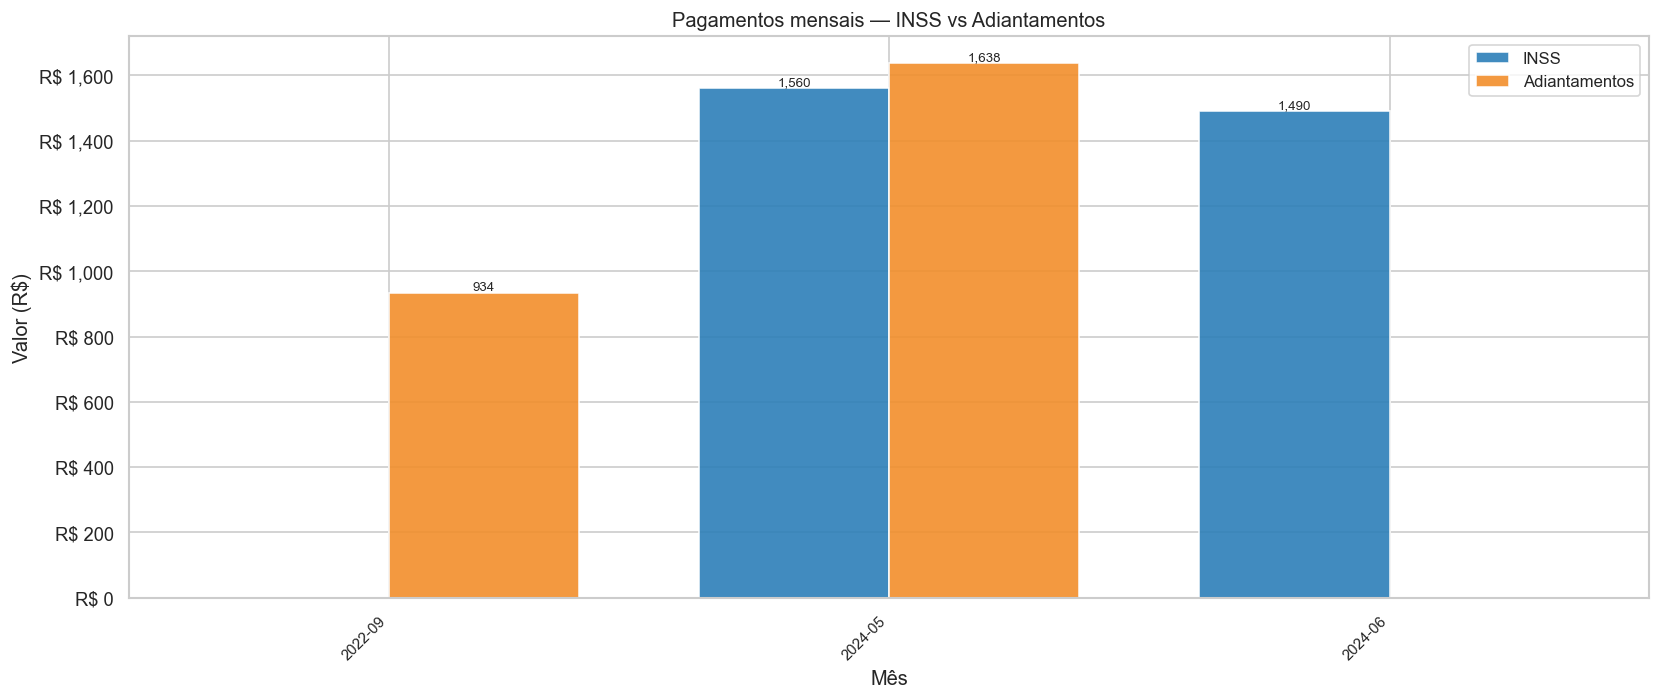

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# 8. INSS e adiantamentos de funcionários (listagem + barras mensais)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PAGAMENTOS: INSS e Adiantamentos de Funcionários")
print("="*80)

# Filtro textual robusto para variações de nomenclatura
mask_inss = df_anom["evento"].astype(str).str.contains(r"inss", case=False, regex=True, na=False)
mask_adiant = df_anom["evento"].astype(str).str.contains(r"\badto\b|adiant", case=False, regex=True, na=False)

df_inss = df_anom.loc[mask_inss, ["mes_ano", "evento", "tipo", "valor", "macro_categoria", "motivo_anomalia"]].copy()
df_adiant = df_anom.loc[mask_adiant, ["mes_ano", "evento", "tipo", "valor", "macro_categoria", "motivo_anomalia"]].copy()

df_inss = df_inss.sort_values(["mes_ano", "valor"], ascending=[True, False])
df_adiant = df_adiant.sort_values(["mes_ano", "valor"], ascending=[True, False])

print("\nINSS — pagamentos encontrados:")
if df_inss.empty:
    print("  Nenhum pagamento de INSS encontrado nas anomalias.")
else:
    print(df_inss.to_string(index=False))
    print(f"  Total INSS: {len(df_inss)} lançamentos | R$ {df_inss['valor'].sum():,.2f}")

print("\nAdiantamentos de Funcionários — pagamentos encontrados:")
if df_adiant.empty:
    print("  Nenhum adiantamento encontrado nas anomalias.")
else:
    print(df_adiant.to_string(index=False))
    print(f"  Total Adiantamentos: {len(df_adiant)} lançamentos | R$ {df_adiant['valor'].sum():,.2f}")

# Série mensal para barras comparativas
serie_inss = df_inss.groupby("mes_ano")["valor"].sum() if not df_inss.empty else pd.Series(dtype=float)
serie_adiant = df_adiant.groupby("mes_ano")["valor"].sum() if not df_adiant.empty else pd.Series(dtype=float)

meses_plot = sorted(set(serie_inss.index).union(set(serie_adiant.index)))

if not meses_plot:
    print("\nSem dados para plotar barras mensais de INSS/Adiantamentos.")
else:
    plot_df = pd.DataFrame({
        "mes_ano": meses_plot,
        "INSS": [float(serie_inss.get(m, 0.0)) for m in meses_plot],
        "Adiantamentos": [float(serie_adiant.get(m, 0.0)) for m in meses_plot],
    })

    x = np.arange(len(plot_df))
    width = 0.38

    fig, ax = plt.subplots(figsize=(14, 6))
    bars_inss = ax.bar(x - width/2, plot_df["INSS"], width, label="INSS", color="#2c7fb8", alpha=0.9)
    bars_adt = ax.bar(x + width/2, plot_df["Adiantamentos"], width, label="Adiantamentos", color="#f28e2b", alpha=0.9)

    ax.set_title("Pagamentos mensais — INSS vs Adiantamentos", fontsize=12)
    ax.set_xlabel("Mês")
    ax.set_ylabel("Valor (R$)")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["mes_ano"], rotation=45, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
    ax.legend(fontsize=10)

    # Rótulos para barras com valor > 0
    for bars in [bars_inss, bars_adt]:
        for b in bars:
            h = b.get_height()
            if h > 0:
                ax.text(b.get_x() + b.get_width()/2, h, f"{h:,.0f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 9. Exportar insights para análise posterior
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("EXPORTAÇÃO: Arquivos de insights")
print("="*80)

# 9a. Ranking por tipo
ranking_tipo.to_csv(CSV_DIR / f"{EXPORT_PREFIX}_01_ranking_tipo.csv", index=False)
print(f"✓ ranking_tipo.csv — {len(ranking_tipo)} tipos")

# 9b. Série temporal mensal
mensal.to_csv(CSV_DIR / f"{EXPORT_PREFIX}_02_tendencia_mensal.csv")
print(f"✓ tendencia_mensal.csv — {len(mensal)} meses")

# 9c. Eventos recorrentes
top_eventos.to_csv(CSV_DIR / f"{EXPORT_PREFIX}_03_eventos_top20.csv", header=["Quantidade"])
print(f"✓ eventos_top20.csv — top 20")

# 9d. Análise por categoria
por_cat.to_csv(CSV_DIR / f"{EXPORT_PREFIX}_04_por_categoria.csv")
print(f"✓ por_categoria.csv — {len(por_cat)} categorias")

# 9e. Data com severidade
df_anom[["mes_ano", "evento", "tipo", "valor", "macro_categoria", "motivo_anomalia", "severidade"]].to_csv(
    CSV_DIR / f"{EXPORT_PREFIX}_05_full_com_severidade.csv", index=False
)
print(f"✓ full_com_severidade.csv — {len(df_anom)} registros com severidade")

print(f"\n=== Total de arquivos exportados: 5 ===")
print(f"Local: {CSV_DIR}")
print(f"Padrão de nome: {EXPORT_PREFIX}_*.csv")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 10. Resumo e recomendações
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("RESUMO EXECUTIVO")
print("="*80)

print(f"\n📊 Estatísticas Gerais:")
print(f"  • Total de anomalias: {len(df_anom):,}")
print(f"  • Período coberto: {df_anom['mes_ano'].min()} → {df_anom['mes_ano'].max()}")
print(f"  • Valor total em anomalias: R$ {df_anom['valor'].sum():,.2f}")
print(f"  • Valor médio por anomalia: R$ {df_anom['valor'].mean():,.2f}")
print(f"  • Tipos de anomalias: {df_anom['motivo_anomalia'].nunique()}")
print(f"  • Macro-categorias afetadas: {df_anom['macro_categoria'].nunique()}")

print(f"\n⚠️ Severidade:")
for sev in ["Crítica", "Alta", "Média", "Baixa"]:
    count = (df_anom["severidade"] == sev).sum()
    valor = df_anom[df_anom["severidade"] == sev]["valor"].sum()
    pct = count / len(df_anom) * 100
    print(f"  • {sev}: {count:,} ({pct:.1f}%) — R$ {valor:,.2f}")

print(f"\n🎯 Principais achados:")
top_tipo = df_anom["motivo_anomalia"].value_counts().index[0]
top_tipo_count = df_anom["motivo_anomalia"].value_counts().values[0]
print(f"  1. Anomalia mais frequente: '{top_tipo}' ({top_tipo_count:,} ocorrências)")

top_cat = df_anom.groupby("macro_categoria")["motivo_anomalia"].count().idxmax()
top_cat_count = df_anom.groupby("macro_categoria")["motivo_anomalia"].count().max()
print(f"  2. Categoria mais afetada: '{top_cat}' ({top_cat_count:,} anomalias)")

top_evt = df_anom["evento"].value_counts().index[0]
top_evt_count = df_anom["evento"].value_counts().values[0]
print(f"  3. Evento recorrente: '{top_evt}' ({top_evt_count:,} vezes)")

print(f"\n💡 Recomendações:")
print(f"  • Investigar causa raiz de '{top_tipo}' → potencial de melhoria significativa")
print(f"  • Revisar categoria '{top_cat}' para recalibrar regras de detecção")
print(f"  • Incluir '{top_evt}' na baseline esperada se for legítimo")
print(f"  • Acompanhar anomalias 'Crítica' e 'Alta' com prioridade")

print(f"\n✓ Análise de anomalias concluída em {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")